# Qwen in Motion: Can Jev Walk?
### BipedalWalker • Qwen 3.5 0.8B • local HF server

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vtavakkoli/simple-jev/blob/main/notebooks/Qwen_Jev_BipedalWalker_Colab.ipynb)

Choose **Runtime → Change runtime type → T4 GPU**, then **Run all**. Python 3.12+ is required. CPU works more slowly. Setup downloads Qwen and starts Simple Jev's Hugging Face server **inside Colab**, on loopback. No external endpoint or Ollama server is needed.

**Can it really walk? This notebook measures that; it does not assume success.** Qwen selects one short coordinated action ID through native `/v1/classifier` scoring. The action ID is converted locally into four motor commands. The notebook also includes a heuristic-teacher mode so the effect of action selection can be tested without pretending that an untrained language model is already a walking policy.

Compare four labeled policies on the same terrain seed:
- **Jev / Qwen:** model decisions from the 24 observations and recent history.
- **Gym heuristic:** Gymnasium's built-in walking controller; a continuous-action sanity check.
- **Quantized heuristic:** the same controller rounded to Qwen's five command levels, to show the effect of discretization.
- **Random:** independent continuous motor commands, included as a weak control.

The default is one **600-step demonstration**. It reports net distance, maximum progress, falls, ground-contact events, return, and API latency, with videos and traces. Enable the final evaluation cell for five new seeds at the standard 1600-step limit. A short clip or high confidence is not evidence of a solved task. Simulation pauses during inference; videos play at simulated time.

In [1]:
#@title 1. Install the HF server and Box2D dependencies
import os, sys, json, pathlib, subprocess, shutil

if sys.version_info < (3, 12):
    raise RuntimeError("Simple Jev requires Python 3.12+. Select a current Colab runtime and reconnect.")

REPO_URL = "https://github.com/vtavakkoli/simple-jev.git"
# Pin the server code inspected for this notebook; model weights use their current HF revision.
SERVER_REVISION = "4eb7775ecd124775c17ceaa012e94f428a0eaaa1"
WORK_DIR = pathlib.Path("/content" if pathlib.Path("/content").is_dir() else pathlib.Path.cwd())
REPO_DIR = WORK_DIR / ("simple-jev-colab-" + SERVER_REVISION[:12])
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "--no-checkout", "--depth", "1", REPO_URL, str(REPO_DIR)], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "--depth", "1", "origin", SERVER_REVISION], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "checkout", "--detach", SERVER_REVISION], check=True)
actual_revision = subprocess.check_output(["git", "-C", str(REPO_DIR), "rev-parse", "HEAD"], text=True).strip()
if actual_revision != SERVER_REVISION:
    raise RuntimeError(f"Unexpected checkout at {REPO_DIR}. Use a fresh runtime or a different REPO_DIR.")

# SWIG must be installed before pip builds Box2D (separate pip invocations).
import site, sysconfig
subprocess.run([sys.executable, "-m", "pip", "install", "swig", "setuptools", "wheel"], check=True)
os.environ["PATH"] = os.pathsep.join([sysconfig.get_path("scripts"), str(pathlib.Path(site.USER_BASE) / "bin"), os.environ["PATH"]])
subprocess.run([sys.executable, "-m", "pip", "install", "-e", str(REPO_DIR / "hf-server"),
               "gymnasium[box2d]==1.3.0", "requests", "numpy", "matplotlib", "pandas",
               "imageio", "imageio-ffmpeg", "peft", "accelerate"], check=True)
# Colab may preinstall an old torchao build. Recent PEFT probes its optional
# TorchAO LoRA dispatcher and raises before standard LoRA injection when that
# installed version is incompatible. This notebook does not use TorchAO, so
# remove it explicitly instead of upgrading another large PyTorch extension.
import importlib.metadata as package_metadata
try:
    torchao_version = package_metadata.version("torchao")
except package_metadata.PackageNotFoundError:
    torchao_version = None
if torchao_version is not None:
    print("Removing optional torchao", torchao_version, "to avoid PEFT dispatcher conflicts.")
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "torchao"], check=True)
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")
os.environ.setdefault("SDL_AUDIODRIVER", "dummy")
# Editable installs created after a Jupyter kernel starts are not guaranteed to
# refresh that kernel's import path. Expose the local checkout explicitly so
# notebook imports and RFDT subprocesses resolve hf_server/common reliably.
for source_path in (REPO_DIR / "hf-server", REPO_DIR):
    source_text = str(source_path)
    if source_text not in sys.path:
        sys.path.insert(0, source_text)
pythonpath_entries = [str(REPO_DIR / "hf-server"), str(REPO_DIR)]
existing_pythonpath = os.environ.get("PYTHONPATH")
if existing_pythonpath:
    pythonpath_entries.append(existing_pythonpath)
os.environ["PYTHONPATH"] = os.pathsep.join(pythonpath_entries)
import importlib
importlib.invalidate_caches()
import hf_server
from common import ClassifierRequest
print("HF server import:", pathlib.Path(hf_server.__file__).resolve())

print("Installed server revision:", actual_revision)

Removing optional torchao 0.10.0 to avoid PEFT dispatcher conflicts.
HF server import: /content/simple-jev-colab-4eb7775ecd12/hf-server/hf_server.py
Installed server revision: 4eb7775ecd124775c17ceaa012e94f428a0eaaa1


In [2]:
#@title 2. Configure the walking experiment
JEV_MODEL = "Qwen/Qwen3.5-0.8B" #@param {type:"string"}
HARDCORE = False #@param {type:"boolean"}
MAX_STEPS = 600 #@param {type:"integer"}
SEEDS = [0]
METHODS = ["heuristic", "heuristic_quantized", "random", "jev"]
ACTION_REPEAT = 4 #@param {type:"integer"}
RECORD_VIDEO = True #@param {type:"boolean"}
HTTP_TIMEOUT = 12
SERVER_STARTUP_TIMEOUT = 900
MODEL_CONTEXT_LIMIT = 4096 # Keep HF inference, RFDT preflight, and training aligned.
HISTORY_LENGTH = 2
# The model chooses one coordinated macro every ACTION_REPEAT frames. A local
# safety/teacher fallback prevents one stalled or unsafe request from ruining a run.
JEV_MODE = "teacher_candidates" #@param ["teacher_candidates", "raw_action"]
TEACHER_FALLBACK = True #@param {type:"boolean"}
CONFIDENCE_THRESHOLD = 0.65 #@param {type:"number"}
MODEL_ACTION_MIX = 0.15 #@param {type:"number"}
# Optional next step: create coordinated expert labels for RFDT fine-tuning.
BUILD_EXPERT_CODEBOOK = True #@param {type:"boolean"}
DEMO_EPISODES = 8 #@param {type:"integer"}
DEMO_STEPS = 600 #@param {type:"integer"}
CODEBOOK_SIZE = 32 #@param {type:"integer"}
DEMO_STRIDE = 2 #@param {type:"integer"}
TRAIN_SELECTOR = True #@param {type:"boolean"}

In [3]:
#@title 3. Start the local HF server and wait for the model
import socket, time, requests

def stop_hf_server():
    """Stop only the child process started by this notebook."""
    process = globals().get("hf_server_process")
    if process is not None and process.poll() is None:
        process.terminate()
        try:
            process.wait(timeout=10)
        except subprocess.TimeoutExpired:
            process.kill()
            process.wait(timeout=10)

def wait_for_hf_server(process, url, model, log_path, timeout=900):
    deadline = time.monotonic() + timeout
    next_update = 0
    while time.monotonic() < deadline:
        if process.poll() is not None:
            tail = log_path.read_text(errors="replace")[-8000:]
            raise RuntimeError(f"HF server exited with code {process.returncode}.\n{tail}")
        try:
            response = requests.get(url + "/health", timeout=2)
            if response.ok:
                health = response.json()
                if health.get("status") == "ready" and health.get("model") == model:
                    return health
                raise RuntimeError(f"Unexpected server on {url}: {health}")
        except requests.RequestException:
            pass
        if time.monotonic() >= next_update:
            print("Downloading/loading the HF model; server log:", log_path, flush=True)
            next_update = time.monotonic() + 15
        time.sleep(1)
    raise TimeoutError(f"HF server did not become ready in {timeout}s.\n" + log_path.read_text(errors="replace")[-8000:])

# Detect hardware in a short-lived child; the notebook does not load model weights.
hardware_probe = """import json, torch
gpu = torch.cuda.is_available()
bf16 = gpu and torch.cuda.get_device_capability(0)[0] >= 8 and torch.cuda.is_bf16_supported()
print(json.dumps({'device': 'cuda' if gpu else 'cpu', 'dtype': 'bfloat16' if bf16 else 'float32',
                  'hardware': torch.cuda.get_device_name(0) if gpu else 'CPU', 'torch': torch.__version__}))
"""
hardware = json.loads(subprocess.check_output([sys.executable, "-c", hardware_probe], text=True))
print("HF server hardware:", hardware)
stop_hf_server()
with socket.socket() as free_socket:
    free_socket.bind(("127.0.0.1", 0))
    JEV_PORT = free_socket.getsockname()[1]
JEV_URL = f"http://127.0.0.1:{JEV_PORT}"
HF_SERVER_LOG = WORK_DIR / "jev_bipedalwalker_server.log"
server_command = [sys.executable, "-u", str(REPO_DIR / "hf-server" / "hf_server.py"),
                  "--model", JEV_MODEL, "--device", hardware["device"], "--dtype", hardware["dtype"],
                  "--host", "127.0.0.1", "--port", str(JEV_PORT), "--max-model-len", str(MODEL_CONTEXT_LIMIT),
                  "--max-batch-size", "4", "--max-batch-tokens", "4096"]
server_env = os.environ.copy()
server_env["PYTHONUNBUFFERED"] = "1"
with HF_SERVER_LOG.open("w") as log_handle:
    hf_server_process = subprocess.Popen(server_command, cwd=REPO_DIR, env=server_env,
                                         stdout=log_handle, stderr=subprocess.STDOUT)
try:
    health = wait_for_hf_server(hf_server_process, JEV_URL, JEV_MODEL, HF_SERVER_LOG, SERVER_STARTUP_TIMEOUT)
except BaseException:
    stop_hf_server()
    raise
print("Ready:", health, "at", JEV_URL)

HF server hardware: {'device': 'cuda', 'dtype': 'float32', 'hardware': 'Tesla T4', 'torch': '2.11.0+cu128'}
Downloading/loading the HF model; server log: /content/jev_bipedalwalker_server.log
Downloading/loading the HF model; server log: /content/jev_bipedalwalker_server.log
Downloading/loading the HF model; server log: /content/jev_bipedalwalker_server.log
Ready: {'status': 'ready', 'model': 'Qwen/Qwen3.5-0.8B'} at http://127.0.0.1:37443


## What Qwen sees and controls
The input is the environment's 24-component observation: hull angle, scaled velocities, joint angles and scaled speeds, foot contacts, and ten lidar fractions. Knee observations include Gymnasium's +1 offset. World position is used only for evaluation and is never passed to Qwen.

The model selects one short action ID, not four independent joint labels. The local selector maps that ID to a complete action ordered **leg 0 hip, leg 0 knee, leg 1 hip, leg 1 knee**. In the pinned Gymnasium implementation, command sign sets motor direction; magnitude sets the maximum motor torque fraction. Zero disables that motor's torque. These are not desired joint angles. In `teacher_candidates` mode, action 0 is the current Gymnasium heuristic action and the other IDs are small coordinated alternatives around it.

The heuristic is an explicitly separate teacher imported from Gymnasium. The `heuristic_quantized` baseline is retained as a negative control: independently rounding each joint can damage an otherwise useful gait. Qwen is queried every `ACTION_REPEAT` frames; request timeouts and low-confidence choices fall back to the teacher when `TEACHER_FALLBACK=True`.

In [4]:
#@title 4. Define observations and the native Jev controller
import collections, csv, datetime, importlib.metadata, time, uuid
import gymnasium as gym
import numpy as np
import pandas as pd
import imageio.v2 as imageio
from gymnasium.envs.box2d.bipedal_walker import (
    BipedalWalkerHeuristics, FPS, TERRAIN_LENGTH, TERRAIN_GRASS, TERRAIN_STEP,
)

ENV_ID = "BipedalWalker-v3"
JOINTS = ["leg0_hip", "leg0_knee", "leg1_hip", "leg1_knee"]
LEVELS = {"n1": -1.0, "n05": -0.5, "zero": 0.0, "p05": 0.5, "p1": 1.0}
OBS_NAMES = ["hull_angle_rad", "hull_angular_velocity_scaled", "horizontal_velocity_scaled",
             "vertical_velocity_scaled", "leg0_hip_angle_rad", "leg0_hip_speed_scaled",
             "leg0_knee_angle_plus1_rad", "leg0_knee_speed_scaled", "leg0_ground_contact",
             "leg1_hip_angle_rad", "leg1_hip_speed_scaled", "leg1_knee_angle_plus1_rad",
             "leg1_knee_speed_scaled", "leg1_ground_contact"] + [f"lidar_fraction_{i}" for i in range(10)]
TASK = """Walk forward in Gymnasium BipedalWalker without falling.
The action vector is [left_hip, left_knee, right_hip, right_knee], each in [-1, 1].
Use hull angle/velocity, horizontal velocity, foot contacts, joints and lidar to balance.
Select one coordinated candidate ID; do not output separate joint labels."""

class JevWalker:
    def __init__(self, url, model, timeout=180):
        self.url, self.model, self.timeout = url.rstrip("/"), model, timeout
        self.http = requests.Session()
        try:
            r = self.http.get(self.url + "/health", timeout=timeout)
            r.raise_for_status()
            health = r.json()
            if health.get("status") != "ready" or health.get("model") != model:
                raise RuntimeError(f"Unexpected server/model: {health}")
        except BaseException:
            self.http.close()
            raise

    def decide(self, observation, history, step):
        observation = np.asarray(observation)
        if observation.shape != (24,) or not np.isfinite(observation).all():
            raise ValueError("Expected 24 finite BipedalWalker observation values")
        state = {"task": TASK, "step": int(step), "action_repeat": ACTION_REPEAT,
                 "observation": dict(zip(OBS_NAMES, np.round(observation, 5).tolist())),
                 "recent_history": list(history)}
        questions = {joint: {"type": "choice", "instructions": f"Choose the current motor command for {joint} to walk forward while maintaining balance.",
                            "criteria": {label: f"Motor command {value:+.1f}" for label, value in LEVELS.items()}}
                     for joint in JOINTS}
        t0 = time.perf_counter()
        r = self.http.post(self.url + "/v1/classifier", json={"model": self.model, "state": state, "questions": questions}, timeout=self.timeout)
        if not r.ok:
            raise RuntimeError(f"HF classifier HTTP {r.status_code}: {r.text[:2000]}")
        raw = r.json()
        if set(raw.get("answers", {})) != set(JOINTS):
            raise ValueError("Missing or extra joint answers")
        labels = [raw["answers"][joint]["choice"] for joint in JOINTS]
        if any(not isinstance(label, str) or label not in LEVELS for label in labels):
            raise ValueError("Invalid motor label; no substitute action is applied")
        action = np.array([LEVELS[label] for label in labels], dtype=np.float32)
        return action, {"latency_ms": (time.perf_counter() - t0) * 1000, "raw": raw}

    def close(self):
        self.http.close()

def new_heuristic():
    controller = BipedalWalkerHeuristics()
    # Ensure the mutable action array is private to each episode.
    controller.a = np.zeros(4)
    return controller

def baseline_action(method, observation, rng, controller):
    levels = np.array(list(LEVELS.values()), dtype=np.float32)
    if method == "random":
        return rng.choice(levels, size=4).astype(np.float32)
    if method not in {"heuristic", "heuristic_quantized"}:
        raise ValueError("Unknown baseline " + method)
    action = np.asarray(controller.step_heuristic(observation), dtype=np.float32)
    if method == "heuristic_quantized":
        action = levels[np.abs(action[:, None] - levels).argmin(axis=1)]
    return np.clip(action, -1, 1).astype(np.float32)

In [5]:
#@title 4b. Use Qwen as a coordinated action selector
# The model selects one short ID. The local teacher turns that ID into a
# complete four-motor action, avoiding independent per-joint quantization.
ACTION_LABELS = [str(i) for i in range(8)]
ACTION_CODEBOOK = globals().get("ACTION_CODEBOOK", None)

def codebook_request(observation, codebook, model):
    """Use exactly the same compact request during RFDT training and rollout."""
    action_vectors = np.asarray(codebook, dtype=np.float32)
    compact_obs = [round(float(x), 3) for x in observation]
    return {"model": model,
            "state": {"observation": compact_obs},
            "questions": {"action": {"type": "choice",
                "instructions": "Select the best four-motor action to walk forward and balance.",
                "criteria": {str(i): str([round(float(x), 2) for x in vector])
                             for i, vector in enumerate(action_vectors)}}}}

def _clip_action(action):
    return np.clip(np.asarray(action, dtype=np.float32), -1.0, 1.0).astype(np.float32)

def _static_action_library():
    return {
        "0": np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32),
        "1": np.array([1.0, 0.35, 1.0, 0.35], dtype=np.float32),
        "2": np.array([-1.0, -0.35, -1.0, -0.35], dtype=np.float32),
        "3": np.array([0.55, 0.25, -0.25, -0.15], dtype=np.float32),
        "4": np.array([-0.25, -0.15, 0.55, 0.25], dtype=np.float32),
        "5": np.array([-0.45, 0.0, 0.45, 0.0], dtype=np.float32),
        "6": np.array([0.45, 0.0, -0.45, 0.0], dtype=np.float32),
        "7": np.array([0.0, -0.65, 0.0, -0.65], dtype=np.float32),
    }

class JevWalker:
    def __init__(self, url, model, timeout=12):
        self.url, self.model, self.timeout = url.rstrip("/"), model, timeout
        self.http = requests.Session()
        self.teacher = BipedalWalkerHeuristics()
        self.teacher.a = np.zeros(4)
        self.previous_action = np.zeros(4, dtype=np.float32)
        self.pending_teacher_action = None
        try:
            r = self.http.get(self.url + "/health", timeout=min(timeout, 5))
            r.raise_for_status()
            health = r.json()
            if health.get("status") != "ready" or health.get("model") != model:
                raise RuntimeError(f"Unexpected server/model: {health}")
        except BaseException:
            self.http.close()
            raise

    def _candidates(self, teacher_action):
        t = _clip_action(teacher_action)
        p = self.previous_action
        # Every candidate is a complete, coordinated four-motor vector.
        candidates = {
            "0": t,
            "1": _clip_action(p),
            "2": _clip_action(0.55 * t),
            "3": _clip_action(t + np.array([0.22, 0.12, -0.12, -0.08])),
            "4": _clip_action(t + np.array([-0.12, -0.08, 0.22, 0.12])),
            "5": _clip_action(np.array([t[2], t[3], t[0], t[1]])),
            "6": np.zeros(4, dtype=np.float32),
            "7": _clip_action(-0.45 * t),
        }
        return candidates

    def decide(self, observation, history, step):
        observation = np.asarray(observation, dtype=np.float32)
        if observation.shape != (24,) or not np.isfinite(observation).all():
            raise ValueError("Expected 24 finite BipedalWalker observation values")
        if JEV_MODE == "raw_action" and ACTION_CODEBOOK is None:
            raise RuntimeError("Independent evaluation needs a saved action codebook; run cell 4c first")
        if JEV_MODE == "raw_action" and ACTION_CODEBOOK is not None:
            teacher_action = np.zeros(4, dtype=np.float32)
        elif self.pending_teacher_action is None:
            teacher_action = _clip_action(self.teacher.step_heuristic(observation))
        else:
            teacher_action = self.pending_teacher_action.copy()
            self.pending_teacher_action = None
        if JEV_MODE == "raw_action" and ACTION_CODEBOOK is not None:
            candidates = {str(i): _clip_action(v) for i, v in enumerate(ACTION_CODEBOOK)}
            descriptions = {str(i): f"coordinated motor vector {np.round(v, 2).tolist()}"
                            for i, v in enumerate(ACTION_CODEBOOK)}
        else:
            candidates = self._candidates(teacher_action)
            descriptions = {
                "0": "teacher action (closest to Gymnasium heuristic)",
                "1": "continue the previous action",
                "2": "damped teacher action for stabilization",
                "3": "teacher action with a left-leg support bias",
                "4": "teacher action with a right-leg support bias",
                "5": "swap the two leg commands",
                "6": "neutral torque",
                "7": "reverse/dampen the teacher action",
            }
        if JEV_MODE == "raw_action" and ACTION_CODEBOOK is not None:
            request = codebook_request(observation, ACTION_CODEBOOK, self.model)
        else:
            request = {"model": self.model,
                       "state": {"task": TASK, "step": int(step), "action_repeat": ACTION_REPEAT,
                                 "observation": dict(zip(OBS_NAMES, np.round(observation, 5).tolist())),
                                 "recent_history": list(history)[-2:],
                                 "candidate_actions": {k: np.round(v, 3).tolist() for k, v in candidates.items()}},
                       "questions": {"action": {"type": "choice",
                           "instructions": "Choose exactly one coordinated action ID. Prefer 0 unless another candidate clearly improves balance.",
                           "criteria": descriptions}}}
        t0 = time.perf_counter()
        try:
            r = self.http.post(self.url + "/v1/classifier", json=request, timeout=self.timeout)
            if not r.ok:
                raise RuntimeError(f"HF classifier HTTP {r.status_code}: {r.text[:2000]}")
            raw = r.json()
            answer = raw.get("answers", {}).get("action", {})
            label = answer.get("choice")
            probabilities = answer.get("probabilities") or {}
            confidence = float(probabilities.get(label, answer.get("confidence", 0.0)) or 0.0)
            if label not in candidates:
                raise ValueError(f"Invalid action ID {label!r}; expected one of {list(candidates)}")
            selected = candidates[label]
            # Raw mode exposes the model's macro choice; teacher_candidates mode
            # keeps the model's choice inside a teacher-generated safe action set.
            follow_teacher = False
            if JEV_MODE == "raw_action":
                selected = candidates[label]
            elif TEACHER_FALLBACK and confidence < CONFIDENCE_THRESHOLD:
                label, selected = "0", teacher_action
                follow_teacher = True
            elif JEV_MODE == "teacher_candidates" and label == "0":
                # Action 0 means “follow the teacher at every physics frame”,
                # rather than holding one stale torque for ACTION_REPEAT frames.
                follow_teacher = True
            else:
                # Keep exploratory model choices close to the stable teacher.
                selected = _clip_action((1.0 - MODEL_ACTION_MIX) * teacher_action + MODEL_ACTION_MIX * selected)
        except (requests.RequestException, RuntimeError, ValueError) as exc:
            if not TEACHER_FALLBACK:
                raise
            label, selected, raw, confidence, follow_teacher = "0", teacher_action, {"fallback": repr(exc)}, 0.0, True
        selected = _clip_action(selected)
        self.previous_action = selected.copy()
        return selected, {"latency_ms": (time.perf_counter() - t0) * 1000,
                          "selected_action": label, "confidence": confidence, "follow_teacher": follow_teacher,
                          "teacher_action": teacher_action.tolist(), "raw": raw}

    def frame_teacher_action(self, observation):
        """Return the teacher action for this exact physics frame."""
        if self.pending_teacher_action is None:
            return _clip_action(self.teacher.step_heuristic(observation))
        action = self.pending_teacher_action.copy()
        self.pending_teacher_action = None
        return action

    def observe(self, observation):
        """Advance the teacher on every physics frame, even when Qwen is repeated."""
        if JEV_MODE == "raw_action" and ACTION_CODEBOOK is not None:
            return
        observation = np.asarray(observation, dtype=np.float32)
        self.pending_teacher_action = _clip_action(self.teacher.step_heuristic(observation))

    def reset_episode(self):
        self.teacher = BipedalWalkerHeuristics()
        self.teacher.a = np.zeros(4)
        self.previous_action = np.zeros(4, dtype=np.float32)
        self.pending_teacher_action = None

    def close(self):
        self.http.close()

def baseline_action(method, observation, rng, controller):
    if method == "random":
        return rng.uniform(-1.0, 1.0, size=4).astype(np.float32)
    if method in {"heuristic", "heuristic_quantized"}:
        action = _clip_action(controller.step_heuristic(observation))
        if method == "heuristic_quantized":
            levels = np.array([-1.0, -0.5, 0.0, 0.5, 1.0], dtype=np.float32)
            action = levels[np.abs(action[:, None] - levels).argmin(axis=1)]
        return _clip_action(action)
    raise ValueError("Unknown baseline " + method)

In [6]:
#@title 4c. Collect heuristic demonstrations and a coordinated action codebook
DEMO_DIR = WORK_DIR / "jev_bipedalwalker_expert_data"
DEMO_DIR.mkdir(parents=True, exist_ok=True)

def _numpy_kmeans(points, k, seed=0, iterations=30):
    points = np.asarray(points, dtype=np.float32)
    if len(points) < k:
        raise ValueError(f"Need at least {k} action samples, got {len(points)}")
    rng = np.random.default_rng(seed)
    centers = points[rng.choice(len(points), size=k, replace=False)].copy()
    for _ in range(iterations):
        distances = ((points[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
        labels = distances.argmin(axis=1)
        updated = centers.copy()
        for j in range(k):
            members = points[labels == j]
            if len(members):
                updated[j] = members.mean(axis=0)
        if np.max(np.abs(updated - centers)) < 1e-4:
            centers = updated
            break
        centers = updated
    return np.clip(centers, -1, 1).astype(np.float32)

def collect_expert_data(episodes=8, max_steps=600, stride=2):
    observations, actions, groups = [], [], []
    for episode in range(episodes):
        env = gym.make(ENV_ID, hardcore=HARDCORE)
        controller = new_heuristic()
        obs, _ = env.reset(seed=1000 + episode)
        for step in range(max_steps):
            action = _clip_action(controller.step_heuristic(obs))
            if step % max(1, stride) == 0:
                observations.append(np.asarray(obs, dtype=np.float32).copy())
                actions.append(action.copy())
                groups.append(episode)
            obs, _, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                break
        env.close()
        print(f"expert episode {episode + 1}/{episodes}: {len(observations)} samples", flush=True)
    return np.asarray(observations, dtype=np.float32), np.asarray(actions, dtype=np.float32), np.asarray(groups)

cached_demonstrations = DEMO_DIR / "heuristic_demonstrations.npz"
if BUILD_EXPERT_CODEBOOK:
    if cached_demonstrations.exists():
        with np.load(cached_demonstrations) as cached:
            demo_obs, demo_actions, demo_groups = (cached[key].copy() for key in ("observations", "actions", "groups"))
            ACTION_CODEBOOK = cached["codebook"].copy()
        if len(ACTION_CODEBOOK) != CODEBOOK_SIZE:
            raise ValueError("Saved codebook size differs from CODEBOOK_SIZE; remove the cached NPZ to regenerate it")
        print("Reusing", len(demo_obs), "saved demonstrations; no recollection needed.")
    else:
        demo_obs, demo_actions, demo_groups = collect_expert_data(DEMO_EPISODES, DEMO_STEPS, DEMO_STRIDE)
        ACTION_CODEBOOK = _numpy_kmeans(demo_actions, CODEBOOK_SIZE, seed=0)
        np.savez_compressed(cached_demonstrations,
                            observations=demo_obs, actions=demo_actions, groups=demo_groups,
                            codebook=ACTION_CODEBOOK)
    dataset_path = DEMO_DIR / "all.jsonl"
    with dataset_path.open("w") as stream:
        for index, (observation, action, group) in enumerate(zip(demo_obs, demo_actions, demo_groups)):
            label = int(np.linalg.norm(ACTION_CODEBOOK - action[None, :], axis=1).argmin())
            request = codebook_request(observation, ACTION_CODEBOOK, JEV_MODEL)
            record = {"id": f"bipedal-demo-{index}", "group_id": f"episode-{int(group)}",
                      "template_version": "v1", "request": request,
                      "targets": {"action": {"answer": str(label)}}}
            stream.write(json.dumps(record) + "\n")
    print("Saved", len(demo_obs), "expert samples and", len(ACTION_CODEBOOK), "coordinated actions to", DEMO_DIR)
else:
    if cached_demonstrations.exists():
        with np.load(cached_demonstrations) as cached:
            ACTION_CODEBOOK = cached["codebook"].copy()
    dataset_path = None
    print("Expert collection disabled; saved codebook loaded when available.")

if TRAIN_SELECTOR:
    if dataset_path is None:
        raise RuntimeError("Set BUILD_EXPERT_CODEBOOK=True before training")
    rfdt_dir = REPO_DIR / "RFDT"
    prepared_dir = DEMO_DIR / "prepared"
    train_output = DEMO_DIR / ("qwen35_0.8b_bipedal_selector_lora_" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S"))
    subprocess.run([sys.executable, str(rfdt_dir / "prepare.py"), "--input", str(dataset_path),
                    "--output", str(prepared_dir), "--validation-fraction", "0.2", "--seed", "42"],
                   cwd=rfdt_dir, check=True)
    # Guard against stale runtimes where cell 1 was not rerun after the PEFT fix.
    try:
        stale_torchao = package_metadata.version("torchao")
    except package_metadata.PackageNotFoundError:
        stale_torchao = None
    if stale_torchao is not None:
        raise RuntimeError(
            f"torchao {stale_torchao} is still installed. Rerun cell 1 (or use a fresh runtime) "
            "so the optional incompatible TorchAO package is removed before PEFT LoRA setup."
        )
    import torch
    # The inference server may prefer float32 on pre-Ampere GPUs, but RFDT training
    # should use fp16 on CUDA when bf16 is unavailable (for example, a Colab T4).
    if torch.cuda.is_available():
        capability = torch.cuda.get_device_capability(0)
        train_dtype = "bfloat16" if capability[0] >= 8 and torch.cuda.is_bf16_supported() else "float16"
    else:
        capability = (0, 0)
        train_dtype = "float32"
    print("RFDT training dtype:", train_dtype, "| CUDA capability:", capability)
    # Compile representative REAL requests with the same compiler used by RFDT.
    # This checks both prompt length and whether every action ID is a stable token.
    from transformers import AutoTokenizer
    from hf_server import PromptCompiler
    from common import ClassifierRequest
    tokenizer = AutoTokenizer.from_pretrained(JEV_MODEL)
    # Use the same context ceiling as the inference server. The v1 classifier
    # prompt repeats the 32 action options by design, so valid requests can exceed 2048 tokens.
    maximum_tokens = MODEL_CONTEXT_LIMIT
    for position in sorted({0, len(demo_obs) // 2, len(demo_obs) - 1}):
        request = ClassifierRequest.model_validate(codebook_request(demo_obs[position], ACTION_CODEBOOK, JEV_MODEL))
        branch = PromptCompiler(tokenizer, max_tokens=maximum_tokens).compile(request).branches[0]
        print(f"RFDT preflight sample {position}: {len(branch.token_ids)}/{maximum_tokens} tokens, "
              f"{len(branch.output_ids)} stable action labels", flush=True)
    del tokenizer
    # The inference server holds another copy of the model on the GPU.
    stop_hf_server()
    train_command = [sys.executable, str(rfdt_dir / "train.py"), "--model", JEV_MODEL,
                     "--train", str(prepared_dir / "train.jsonl"),
                     "--validation", str(prepared_dir / "validation.jsonl"),
                     "--output", str(train_output), "--lora", "--lora-rank", "8",
                     "--dtype", train_dtype, "--batch-size", "1",
                     "--gradient-accumulation", "16", "--gradient-checkpointing",
                     "--epochs", "2", "--learning-rate", "0.0001", "--max-length", str(maximum_tokens)]
    print("Training with:", " ".join(train_command), flush=True)
    training_log = DEMO_DIR / (train_output.name + ".log")
    training_tail = []
    with training_log.open("w") as log_stream:
        training_process = subprocess.Popen(
            train_command, cwd=rfdt_dir, env=os.environ.copy(),
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
            text=True, bufsize=1,
        )
        assert training_process.stdout is not None
        for line in training_process.stdout:
            print(line, end="", flush=True)
            log_stream.write(line)
            log_stream.flush()
            training_tail.append(line)
            if len(training_tail) > 200:
                training_tail.pop(0)
        training_returncode = training_process.wait()
    if training_returncode != 0:
        if training_returncode < 0:
            exit_detail = f"terminated by signal {-training_returncode}"
        else:
            exit_detail = f"exit code {training_returncode}"
        raise RuntimeError(
            f"RFDT training failed ({exit_detail}). Full log: {training_log}\n"
            + "Last trainer output:\n" + "".join(training_tail)
        )
    print("RFDT selector adapter saved to", train_output)
    # RFDT --lora writes an adapter. Merge it so the existing HF server can load
    # one ordinary Transformers checkpoint on the next startup.
    import torch
    from transformers import (
        AutoConfig, AutoModelForCausalLM, AutoModelForImageTextToText,
        AutoTokenizer, Qwen3_5ForCausalLM,
    )
    from peft import PeftModel
    base_config = AutoConfig.from_pretrained(JEV_MODEL)
    if base_config.model_type == "qwen3_5":
        # Match RFDT training: this experiment is text-only, so do not reload
        # the unused Qwen3.5 vision stack just to merge the LoRA adapter.
        loader = Qwen3_5ForCausalLM
    else:
        loader = (AutoModelForImageTextToText if base_config.model_type in {"gemma4", "qwen3_5_moe"}
                  else AutoModelForCausalLM)
    base_model = loader.from_pretrained(JEV_MODEL, dtype=getattr(torch, train_dtype), device_map="auto")
    merged_model = PeftModel.from_pretrained(base_model, train_output).merge_and_unload()
    merged_output = DEMO_DIR / ("qwen35_0.8b_bipedal_selector_merged_" + datetime.datetime.now().strftime("%Y%m%d_%H%M%S"))
    merged_model.save_pretrained(merged_output, safe_serialization=True)
    AutoTokenizer.from_pretrained(JEV_MODEL).save_pretrained(merged_output)
    np.save(merged_output / "walker_action_codebook.npy", ACTION_CODEBOOK)
    del merged_model, base_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print("Merged checkpoint saved to", merged_output)
    JEV_MODEL = str(merged_output)
    JEV_MODE = "raw_action"
    TEACHER_FALLBACK = False
    server_command[server_command.index("--model") + 1] = JEV_MODEL
    with HF_SERVER_LOG.open("w") as log_handle:
        hf_server_process = subprocess.Popen(server_command, cwd=REPO_DIR, env=server_env,
                                             stdout=log_handle, stderr=subprocess.STDOUT)
    health = wait_for_hf_server(hf_server_process, JEV_URL, JEV_MODEL, HF_SERVER_LOG, SERVER_STARTUP_TIMEOUT)
    print("Trained selector ready:", health, "mode:", JEV_MODE, "teacher fallback:", TEACHER_FALLBACK)
else:
    print("TRAIN_SELECTOR=False: demonstrations are ready; enable it to fine-tune Qwen with RFDT.")

expert episode 1/8: 300 samples
expert episode 2/8: 600 samples
expert episode 3/8: 900 samples
expert episode 4/8: 1200 samples
expert episode 5/8: 1286 samples
expert episode 6/8: 1586 samples
expert episode 7/8: 1886 samples
expert episode 8/8: 2176 samples
Saved 2176 expert samples and 32 coordinated actions to /content/jev_bipedalwalker_expert_data
RFDT training dtype: float16 | CUDA capability: (7, 5)
RFDT preflight sample 0: 2760/4096 tokens, 32 stable action labels
RFDT preflight sample 1088: 2759/4096 tokens, 32 stable action labels
RFDT preflight sample 2175: 2759/4096 tokens, 32 stable action labels
Training with: /usr/bin/python3 /content/simple-jev-colab-4eb7775ecd12/RFDT/train.py --model Qwen/Qwen3.5-0.8B --train /content/jev_bipedalwalker_expert_data/prepared/train.jsonl --validation /content/jev_bipedalwalker_expert_data/prepared/validation.jsonl --output /content/jev_bipedalwalker_expert_data/qwen35_0.8b_bipedal_selector_lora_20260920_102433 --lora --lora-rank 8 --dtyp

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged checkpoint saved to /content/jev_bipedalwalker_expert_data/qwen35_0.8b_bipedal_selector_merged_20260920_165657
Downloading/loading the HF model; server log: /content/jev_bipedalwalker_server.log
Trained selector ready: {'status': 'ready', 'model': '/content/jev_bipedalwalker_expert_data/qwen35_0.8b_bipedal_selector_merged_20260920_165657'} mode: raw_action teacher fallback: False


In [7]:
#@title 5. Inspect one real Qwen motor decision
probe_env = gym.make(ENV_ID, hardcore=HARDCORE)
probe_client = None
try:
    obs, _ = probe_env.reset(seed=int(SEEDS[0]))
    probe_client = JevWalker(JEV_URL, JEV_MODEL, HTTP_TIMEOUT)
    action, details = probe_client.decide(obs, [], 0)
    assert probe_env.action_space.contains(action)
    print("Model:", JEV_MODEL, "| first-call latency (ms):", round(details["latency_ms"], 1))
    print("Motor commands:", dict(zip(JOINTS, action.tolist())))
    print("Rough Qwen episode time if it reaches the cap (minutes):", round(MAX_STEPS / ACTION_REPEAT * details["latency_ms"] / 60000, 1), "— first-call timing includes warm-up effects")
    print(json.dumps(details["raw"], indent=2))
finally:
    probe_env.close()
    if probe_client is not None:
        probe_client.close()

Model: /content/jev_bipedalwalker_expert_data/qwen35_0.8b_bipedal_selector_merged_20260920_165657 | first-call latency (ms): 2436.8
Motor commands: {'leg0_hip': 0.24503153562545776, 'leg0_knee': -0.9878793954849243, 'leg1_hip': -0.04174850881099701, 'leg1_knee': 0.373531699180603}
Rough Qwen episode time if it reaches the cap (minutes): 6.1 — first-call timing includes warm-up effects
{
  "model": "/content/jev_bipedalwalker_expert_data/qwen35_0.8b_bipedal_selector_merged_20260920_165657",
  "answers": {
    "action": {
      "type": "choice",
      "confidence": 0.8622345924377441,
      "probabilities": {
        "0": 0.0009484784095548093,
        "1": 0.0025576844345778227,
        "2": 0.0009448723867535591,
        "3": 0.013405808247625828,
        "4": 0.0022116387262940407,
        "5": 0.0049280631355941296,
        "6": 0.0345153771340847,
        "7": 0.0010719721904024482,
        "8": 0.005036516115069389,
        "9": 0.013461845926940441,
        "10": 0.000482016388559

In [8]:
#@title 6. Benchmark with explicit fall, distance, and contact measurements
def run_walker(methods, seeds, max_steps=600, record_video=True):
    allowed = {"jev", "random", "heuristic", "heuristic_quantized"}
    if not methods or len(set(methods)) != len(methods) or set(methods) - allowed:
        raise ValueError("Choose distinct supported methods")
    if not seeds or len(set(seeds)) != len(seeds) or max_steps < 1 or ACTION_REPEAT < 1:
        raise ValueError("Use distinct seeds and positive step/repeat limits")
    out = WORK_DIR / "jev_bipedalwalker_results" / (datetime.datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:6])
    out.mkdir(parents=True)
    versions = {p: importlib.metadata.version(p) for p in ["gymnasium", "numpy", "imageio", "requests"]}
    config = {"model": JEV_MODEL, "server_url": JEV_URL, "server_revision": SERVER_REVISION,
              "hardware": hardware, "versions": versions, "env": ENV_ID, "hardcore": HARDCORE,
              "methods": methods, "seeds": list(seeds), "max_steps": max_steps, "action_repeat": ACTION_REPEAT,
              "history_length": HISTORY_LENGTH, "jev_mode": JEV_MODE, "teacher_fallback": TEACHER_FALLBACK,
              "confidence_threshold": CONFIDENCE_THRESHOLD, "model_action_mix": MODEL_ACTION_MIX,
              "levels": LEVELS, "observation_names": OBS_NAMES,
              "task_prompt": TASK, "mode": "synchronous_simulation", "fps": FPS,
              "distance_units": "Box2D world units", "positions_used_only_for_evaluation": True}
    (out / "config.json").write_text(json.dumps(config, indent=2))
    rows = []
    for method in methods:
        for episode, seed in enumerate(seeds):
            video = bool(record_video and episode == 0)
            env = gym.make(ENV_ID, hardcore=HARDCORE, render_mode="rgb_array" if video else None)
            client = writer = None
            obs, _ = env.reset(seed=int(seed))
            start_x = float(env.unwrapped.hull.position.x)
            x = peak_x = start_x
            controller = new_heuristic()
            rng = np.random.default_rng(int(seed) + 10000)
            history = collections.deque(maxlen=HISTORY_LENGTH)
            previous_contacts = np.array([obs[8], obs[13]]) > 0.5
            touches = [0, 0]
            alternating_touches = 0
            last_single_touch = None
            steps = calls = failures = 0
            teacher_follow_decisions = 0
            selected_action_counts = collections.Counter()
            total_return = 0.0
            latencies, trajectory = [], []
            terminated = truncated = False
            status, error = "ok", ""
            episode_start = None
            try:
                if method == "jev":
                    client = JevWalker(JEV_URL, JEV_MODEL, HTTP_TIMEOUT)
                    _, warmup = client.decide(obs, [], 0)
                    (out / f"{method}_seed{seed}_warmup.json").write_text(json.dumps(warmup, indent=2))
                    client.reset_episode()
                if video:
                    writer = imageio.get_writer(str(out / f"{method}_seed{seed}.mp4"), fps=FPS, macro_block_size=1)
                    writer.append_data(env.render())
                episode_start = time.perf_counter()
                with (out / f"{method}_seed{seed}.jsonl").open("w") as trace:
                    while steps < max_steps and not (terminated or truncated):
                        before = obs.copy()
                        meta = {}
                        try:
                            if client is not None:
                                calls += 1
                                action, meta = client.decide(obs, history, steps)
                                latencies.append(meta["latency_ms"])
                                selected_action_counts[str(meta.get("selected_action"))] += 1
                                teacher_follow_decisions += int(meta.get("follow_teacher", False))
                            else:
                                # Baselines are evaluated inside the frame loop
                                # so the heuristic is updated at every physics step.
                                action = np.zeros(4, dtype=np.float32)
                            if not env.action_space.contains(action):
                                raise ValueError("Action outside environment bounds")
                        except Exception as exc:
                            failures += 1
                            trace.write(json.dumps({"step": steps, "decision_error": repr(exc)}) + "\n")
                            raise
                        reward_chunk = 0.0
                        last_executed_action = action.copy()
                        for frame_index in range(min(ACTION_REPEAT, max_steps - steps)):
                            # Baselines update every physics frame. Jev normally
                            # holds its selected macro, but action 0 means “follow
                            # the synchronized teacher” at every frame.
                            if client is None:
                                frame_action = baseline_action(method, obs, rng, controller)
                            elif (meta.get("follow_teacher", False)
                                  and JEV_MODE == "teacher_candidates" and frame_index > 0):
                                frame_action = client.frame_teacher_action(obs)
                            else:
                                frame_action = action
                            if not env.action_space.contains(frame_action):
                                raise ValueError("Frame action outside environment bounds")
                            last_executed_action = np.asarray(frame_action, dtype=np.float32).copy()
                            obs, reward, terminated, truncated, _ = env.step(frame_action)
                            steps += 1
                            if client is not None:
                                client.observe(obs)
                            total_return += float(reward)
                            reward_chunk += float(reward)
                            x = float(env.unwrapped.hull.position.x)
                            peak_x = max(peak_x, x)
                            contacts = np.array([obs[8], obs[13]]) > 0.5
                            landed = np.flatnonzero(contacts & ~previous_contacts)
                            for foot in landed:
                                touches[int(foot)] += 1
                            if len(landed) == 1:
                                foot = int(landed[0])
                                if last_single_touch is not None and last_single_touch != foot:
                                    alternating_touches += 1
                                last_single_touch = foot
                            previous_contacts = contacts
                            trajectory.append({"step": steps, "time_s": steps / FPS, "net_distance": x - start_x,
                                               "return": total_return, "hull_angle_rad": float(obs[0]),
                                               "leg0_contact": int(contacts[0]), "leg1_contact": int(contacts[1])})
                            if writer is not None:
                                writer.append_data(env.render())
                            if terminated or truncated:
                                break
                        history.append({"observation": np.round(before, 5).tolist(), "action": last_executed_action.tolist(),
                                        "reward": reward_chunk})
                        trace.write(json.dumps({"step": steps, "before": before.tolist(), "action": last_executed_action.tolist(),
                                                "after": obs.tolist(), "reward": reward_chunk, **meta}) + "\n")
                        trace.flush()
                        if steps % 50 == 0:
                            print(f"{method} seed={seed}: {steps}/{max_steps} steps, distance={x-start_x:.2f}, return={total_return:.1f}", flush=True)
            except Exception as exc:
                status, error = "failed", repr(exc)
                print(f"{method}: {error}. No substitute policy was applied.")
            finally:
                fallen = bool(env.unwrapped.game_over)
                left_boundary = x < 0
                finish_x = (TERRAIN_LENGTH - TERRAIN_GRASS) * TERRAIN_STEP
                completed = bool(terminated and x > finish_x and not fallen and not left_boundary)
                env.close()
                if writer is not None:
                    writer.close()
                if client is not None:
                    client.close()
            row = {"method": method, "seed": int(seed), "status": status, "return": total_return, "steps": steps,
                   "net_distance": x - start_x, "peak_distance": peak_x - start_x,
                   "fallen": fallen, "left_boundary": bool(left_boundary), "course_completed": completed,
                   "return_ge_300": bool(status == "ok" and total_return >= 300),
                   "leg0_touchdowns": touches[0], "leg1_touchdowns": touches[1], "alternating_touchdowns": alternating_touches,
                   "terminated": bool(terminated), "truncated": bool(truncated),
                   "capped_by_benchmark": steps >= max_steps and not (terminated or truncated),
                   "api_calls": calls, "decision_failures": failures,
                   "teacher_follow_decisions": teacher_follow_decisions,
                   "teacher_follow_rate": float(teacher_follow_decisions / calls) if calls else None,
                   "selected_action_counts": dict(selected_action_counts),
                   "latency_mean_ms": float(np.mean(latencies)) if latencies else None,
                   "latency_p95_ms": float(np.percentile(latencies, 95)) if latencies else None,
                   "simulated_seconds": steps / FPS,
                   "episode_wall_seconds": time.perf_counter() - episode_start if episode_start is not None else None,
                   "error": error}
            rows.append(row)
            pd.DataFrame(rows).to_csv(out / "episodes.csv", index=False)
            pd.DataFrame(trajectory).to_csv(out / f"{method}_seed{seed}_trajectory.csv", index=False)
            print({k: row[k] for k in ["method", "seed", "return", "net_distance", "fallen", "course_completed", "status"]})
            if status != "ok":
                break
    print("Saved results:", out)
    return rows, out

In [9]:
#@title 7. Run the walking comparison
rows, output_dir = run_walker(METHODS, SEEDS, MAX_STEPS, RECORD_VIDEO)

heuristic seed=0: 100/600 steps, distance=1.01, return=2.1
heuristic seed=0: 200/600 steps, distance=5.80, return=19.9
heuristic seed=0: 300/600 steps, distance=12.06, return=43.6
heuristic seed=0: 400/600 steps, distance=18.02, return=66.4
heuristic seed=0: 500/600 steps, distance=24.20, return=89.3
heuristic seed=0: 600/600 steps, distance=29.71, return=110.5
{'method': 'heuristic', 'seed': 0, 'return': 110.53860329394229, 'net_distance': 29.708829402923584, 'fallen': False, 'course_completed': False, 'status': 'ok'}
heuristic_quantized seed=0: 100/600 steps, distance=-2.15, return=-12.4
{'method': 'heuristic_quantized', 'seed': 0, 'return': -116.07168531115167, 'net_distance': -2.7492505311965942, 'fallen': True, 'course_completed': False, 'status': 'ok'}
random seed=0: 100/600 steps, distance=1.27, return=-0.2
{'method': 'random', 'seed': 0, 'return': -104.04126280662604, 'net_distance': 1.807662010192871, 'fallen': True, 'course_completed': False, 'status': 'ok'}
jev seed=0: 100/6

,method,seed,status,return,net_distance,peak_distance,fallen,course_completed,alternating_touchdowns,capped_by_benchmark,latency_mean_ms,teacher_follow_rate
0,heuristic,0,ok,110.538603,29.708829,29.708829,False,False,18,True,NaN,NaN
1,heuristic_quantized,0,ok,-116.071685,-2.749251,0.001387,True,False,2,False,NaN,NaN
2,random,0,ok,-104.041263,1.807662,1.807662,True,False,13,False,NaN,NaN
3,jev,0,ok,-103.348120,2.015176,2.018605,True,False,3,False,1832.276982,0.0


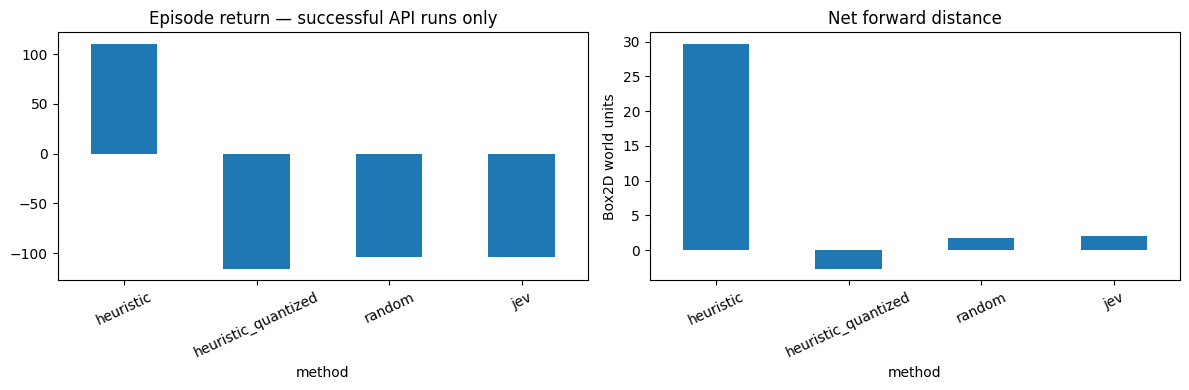

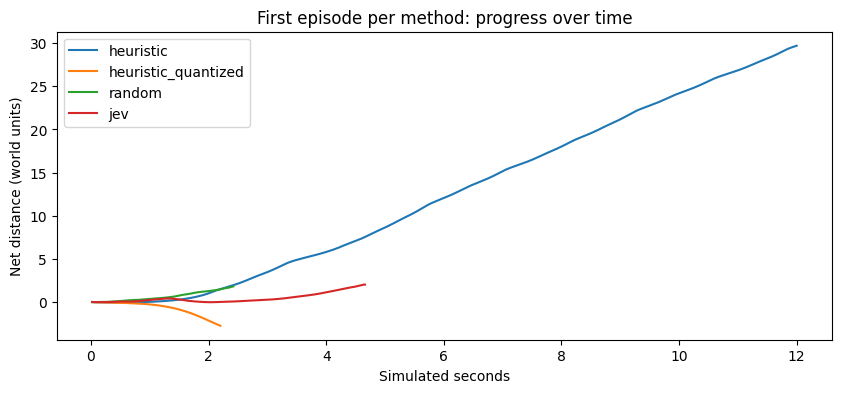

heuristic_quantized_seed0.mp4


heuristic_seed0.mp4


jev_seed0.mp4


random_seed0.mp4


heuristic | attempted: 1 | API/setup errors: 0 | falls: 0 | course completions: 0
heuristic_quantized | attempted: 1 | API/setup errors: 0 | falls: 1 | course completions: 0
random | attempted: 1 | API/setup errors: 0 | falls: 1 | course completions: 0
jev | attempted: 1 | API/setup errors: 0 | falls: 1 | course completions: 0
Forward progress plus alternating contacts is evidence to inspect in the video; neither alone proves stable walking.


In [10]:
#@title 8. Watch the walker and compare measured progress
import matplotlib.pyplot as plt
from IPython.display import display, Video

def show_results(rows, folder):
    table = pd.DataFrame(rows)
    display(table[["method", "seed", "status", "return", "net_distance", "peak_distance", "fallen",
                   "course_completed", "alternating_touchdowns", "capped_by_benchmark", "latency_mean_ms",
                   "teacher_follow_rate"]])
    ok = table[table.status == "ok"]
    if len(ok):
        means = ok.groupby("method", sort=False)[["return", "net_distance"]].mean()
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        means["return"].plot.bar(ax=axes[0], title="Episode return — successful API runs only", rot=25)
        means["net_distance"].plot.bar(ax=axes[1], title="Net forward distance", rot=25)
        axes[1].set_ylabel("Box2D world units")
        plt.tight_layout(); plt.show()
    fig, ax = plt.subplots(figsize=(10, 4))
    for method in table.method.unique():
        seed = int(table[table.method == method].iloc[0].seed)
        path = folder / f"{method}_seed{seed}_trajectory.csv"
        if path.exists() and path.stat().st_size > 1:
            trace = pd.read_csv(path)
            ax.plot(trace.time_s, trace.net_distance, label=method)
    ax.set(xlabel="Simulated seconds", ylabel="Net distance (world units)", title="First episode per method: progress over time")
    if ax.lines: ax.legend()
    plt.show()
    for path in sorted(folder.glob("*.mp4")):
        print(path.name)
        display(Video(str(path), embed=True, width=640))
    for method in table.method.unique():
        result = table[table.method == method]
        print(method, "| attempted:", len(result), "| API/setup errors:", sum(result.status != "ok"),
              "| falls:", int(result.fallen.sum()), "| course completions:", int(result.course_completed.sum()))
    print("Forward progress plus alternating contacts is evidence to inspect in the video; neither alone proves stable walking.")

show_results(rows, output_dir)

In [11]:
#@title 9. Optional full-episode evaluation on five new seeds
RUN_FULL_EVALUATION = False #@param {type:"boolean"}
if RUN_FULL_EVALUATION:
    eval_seeds = [101, 102, 103, 104, 105]
    eval_rows, eval_dir = run_walker(METHODS, eval_seeds, 2000 if HARDCORE else 1600, RECORD_VIDEO)
    show_results(eval_rows, eval_dir)
    for method in METHODS:
        attempts = [r for r in eval_rows if r["method"] == method]
        good = [r for r in attempts if r["status"] == "ok"]
        print(method, "planned:", len(eval_seeds), "completed without API errors:", len(good),
              "mean return:", float(np.mean([r["return"] for r in good])) if good else None)
else:
    print("Enable RUN_FULL_EVALUATION only after checking the first videos. Many local model calls may take a long time.")

Enable RUN_FULL_EVALUATION only after checking the first videos. Many local model calls may take a long time.


In [12]:
#@title 10. Download the latest results (videos, CSV, raw decisions)
DOWNLOAD_RESULTS = False #@param {type:"boolean"}
if DOWNLOAD_RESULTS:
    folder = eval_dir if RUN_FULL_EVALUATION else output_dir
    archive = shutil.make_archive(str(folder), "zip", root_dir=folder)
    try:
        from google.colab import files
        files.download(archive)
    except ImportError:
        print("Results ZIP:", archive)

## How to answer “can it really walk?”
Inspect **Qwen's own video and row**, separately from the heuristic. Look for sustained forward movement with alternating foot support, an upright hull, and no fall. `net_distance` can be positive even if the walker later falls; `peak_distance` also counts temporary progress. Contact events can include chatter or hopping, so they are diagnostic counts, not certified steps.

`course_completed` means reaching the far end without a recorded fall. A return of 300 is the documented task target; a single short episode does not establish that the model solves it reliably. Use complete episodes and held-out seeds. Failed API episodes stay visible, and partial returns must not be treated as completed trials.

The continuous heuristic is a sanity check, not a learned baseline. Compare its quantized variant to see whether the five command levels impede control. All methods share the terrain seeds, step limits, and action-repeat setting. No controller receives future states; evaluation reads hull position without passing it to Qwen.

The expert-data cell reuses saved demonstrations when rerun. It creates an RFDT dataset using the same compact prompt used for independent inference, checks prompt length and tokenizer labels, then stops the local inference server to free GPU memory before training. Set `TRAIN_SELECTOR=True` to fine-tune Qwen. After a successful run it merges the LoRA adapter, restarts the server with the merged checkpoint, and switches automatically to `JEV_MODE="raw_action"`, `TEACHER_FALLBACK=False`. Run the probe and benchmark cells after it. A successful training run does not guarantee walking; compare independent Jev against the heuristic on held-out seeds. `teacher_follow_rate=0` confirms fallback is disabled in independent mode.

**Troubleshooting:** reconnect after changing runtime hardware. If setup fails building Box2D, rerun the SWIG installation before installing the Box2D extra. Server startup errors show the log tail; inspect `HF_SERVER_LOG` for details. Run `stop_hf_server()` when finished to release model memory. Downloads and installs require network access; subsequent inference stays inside the runtime.

Sources: [Gymnasium BipedalWalker](https://gymnasium.farama.org/environments/box2d/bipedal_walker/), [Gymnasium source and heuristic](https://github.com/Farama-Foundation/Gymnasium/blob/v1.3.0/gymnasium/envs/box2d/bipedal_walker.py), [Qwen 3.5 0.8B](https://huggingface.co/Qwen/Qwen3.5-0.8B), [Simple Jev HF server](https://github.com/vtavakkoli/simple-jev/tree/main/hf-server).